# Presentation Koen and Frank 

*Plotting code* 

## Importing and downloading relevant data 

In [13]:
import falnama
import maxrf4u as mx 
import matplotlib.pyplot as plt
import re 

In [3]:
maxrf = falnama.Falnama_maxrf_data()

Just downloading all maxrf data via my wifi at home to work remotely took me more then two hours!  

In [3]:
maxrf.download_all()

100%|█████████████████████████████████████| 1.95G/1.95G [00:00<00:00, 1.73TB/s]


Checked 1/16 files


100%|█████████████████████████████████████| 7.75G/7.75G [00:00<00:00, 9.64TB/s]


Checked 2/16 files


100%|█████████████████████████████████████| 7.97G/7.97G [00:00<00:00, 6.58TB/s]


...

Checked 14/16 files


100%|█████████████████████████████████████| 1.98G/1.98G [00:00<00:00, 1.56TB/s]


Checked 15/16 files


100%|█████████████████████████████████████| 2.07G/2.07G [00:00<00:00, 1.23TB/s]


Checked 16/16 files
All data is up to date!


## Data cubes overview

In [15]:
datastack_files = maxrf.get_datastack_files()
object_nums = [re.sub(r'.*(WM-71803-\d\d).*', r'\1', dsf) for dsf in datastack_files]


In [6]:
ds_list = [mx.DataStack(dsf) for dsf in datastack_files]

In [46]:
imvis_list = [ds.read('imvis_reg') for ds in ds_list]
extent_list = [ds.read('imvis_extent') for ds in ds_list]

In [9]:
len(imvis_list)

16

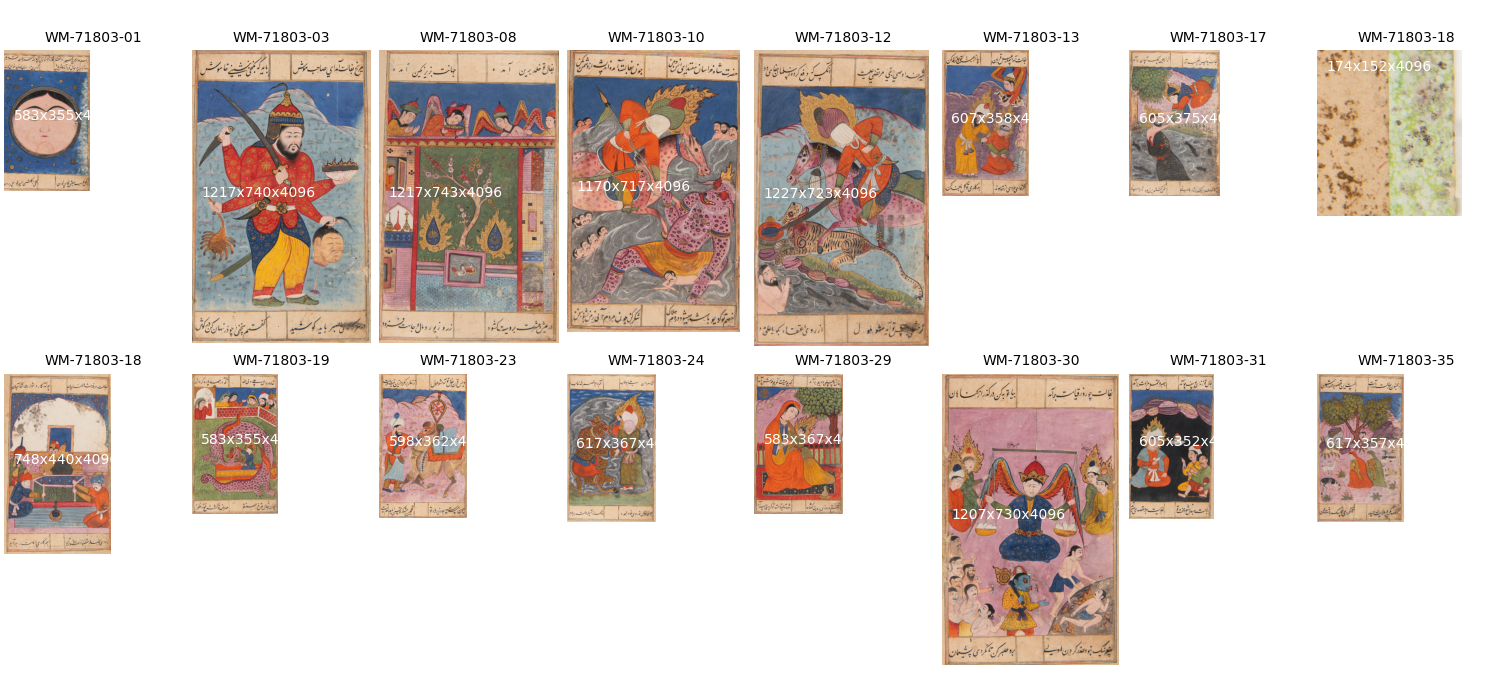

In [54]:
fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[15, 7], layout='compressed')
axs = axs.flatten()
for ax, im, extent, num, [h, w, d] in zip(axs, imvis_list, extent_list, object_nums, cube_shapes): 
    ax.imshow(im, extent=extent)
    ax.axis('off')
    ax.set_xlim([0, w_max])
    ax.set_ylim([h_max, 0])
    ax.text(40, h*0.5, f'{h}x{w}x{d}', fontsize=10, color='w')
    ax.set_title(f'{num}', fontsize=10)

I also need all shapes...

In [19]:
cubes = [ds.read('maxrf_cube', compute=False) for ds in ds_list]

In [20]:
cube_shapes = [c.shape for c in cubes]

Next, I need a function to plot these 2D images in 3D: https://stackoverflow.com/questions/60180679/rbg-image-as-texture-for-a-3d-cube-using-matplotlib 

In [53]:
h_max, w_max, d_max = np.array(cube_shapes).max(axis=0)

[Text(0.5, 0, 'x'), Text(0.5, 0.5, 'y'), Text(0.5, 0, 'z')]

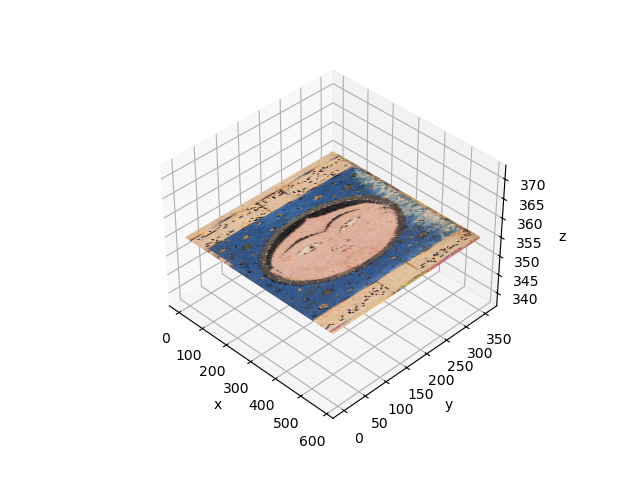

In [44]:
import numpy as np
import matplotlib.image as image
import matplotlib.pyplot as plt

#C = image.imread('d:/timg.png')

C = imvis_list[0] / 256

xp, yp, __ = C.shape

x = np.arange(0, xp, 1)
y = np.arange(0, yp, 1)
Y, X = np.meshgrid(y, x)

#fig = plt.figure(figsize=(12,9))
#ax = fig.gca(projection='3d')

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.dist=6.2
ax.view_init(elev=38, azim=-45)

ax.plot_surface(X, Y, X-X+yp, facecolors=C,
                rstride=4, cstride=4,
                antialiased=True, shade=False)

ax.set(xlabel="x", ylabel="y", zlabel="z") 

#ax.plot_surface(X, X-X, Y, facecolors=np.fliplr(C.transpose((1,0,2))),
#                rstride=2, cstride=2,
#                antialiased=True, shade=False)
#
#ax.plot_surface(X-X+xp, X, Y, facecolors=np.fliplr(C.transpose((1,0,2))),
#                rstride=2, cstride=2,
#                antialiased=True, shade=False)

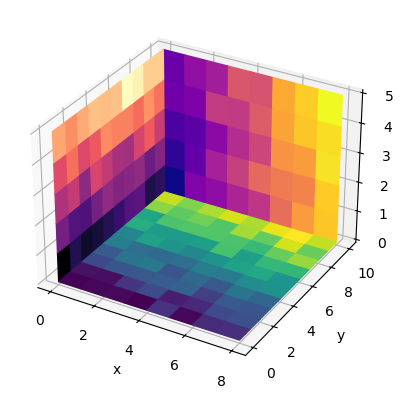

In [22]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import Normalize


def imshow3d(ax, array, value_direction='z', pos=0, norm=None, cmap=None):
    """
    Display a 2D array as a  color-coded 2D image embedded in 3d.

    The image will be in a plane perpendicular to the coordinate axis *value_direction*.

    Parameters
    ----------
    ax : Axes3D
        The 3D Axes to plot into.
    array : 2D numpy array
        The image values.
    value_direction : {'x', 'y', 'z'}
        The axis normal to the image plane.
    pos : float
        The numeric value on the *value_direction* axis at which the image plane is
        located.
    norm : `~matplotlib.colors.Normalize`, default: Normalize
        The normalization method used to scale scalar data. See `imshow()`.
    cmap : str or `~matplotlib.colors.Colormap`, default: :rc:`image.cmap`
        The Colormap instance or registered colormap name used to map scalar data
        to colors.
    """
    if norm is None:
        norm = Normalize()
    colors = plt.get_cmap(cmap)(norm(array))

    if value_direction == 'x':
        nz, ny = array.shape
        zi, yi = np.mgrid[0:nz + 1, 0:ny + 1]
        xi = np.full_like(yi, pos)
    elif value_direction == 'y':
        nx, nz = array.shape
        xi, zi = np.mgrid[0:nx + 1, 0:nz + 1]
        yi = np.full_like(zi, pos)
    elif value_direction == 'z':
        ny, nx = array.shape
        yi, xi = np.mgrid[0:ny + 1, 0:nx + 1]
        zi = np.full_like(xi, pos)
    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")
    ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, shade=False)


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set(xlabel="x", ylabel="y", zlabel="z")

nx, ny, nz = 8, 10, 5
data_xy = np.arange(ny * nx).reshape(ny, nx) + 15 * np.random.random((ny, nx))
data_yz = np.arange(nz * ny).reshape(nz, ny) + 10 * np.random.random((nz, ny))
data_zx = np.arange(nx * nz).reshape(nx, nz) + 8 * np.random.random((nx, nz))

imshow3d(ax, data_xy)
imshow3d(ax, data_yz, value_direction='x', cmap='magma')
imshow3d(ax, data_zx, value_direction='y', pos=ny, cmap='plasma')

plt.show()

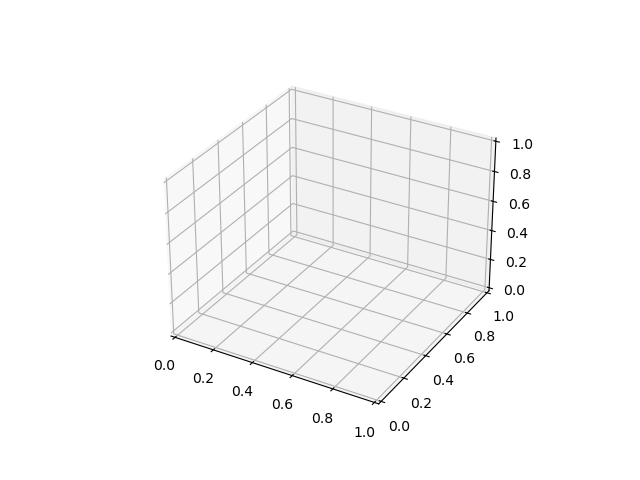

In [28]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

In [27]:
ax.plot_surface()

In [25]:
%matplotlib widget

In [29]:
data_xy.shape

(10, 8)

In [30]:
data_xy

array([[ 6.6578206 ,  7.78455675,  8.42124803,  6.16665367, 18.17338724,
         7.68081013, 16.36452563, 17.57662527],
       [ 9.83546513,  9.4245685 , 19.07514723, 25.27677025, 13.35729752,
        15.96347963, 25.28351128, 26.98683321],
       [24.71728182, 28.75518872, 29.17564452, 30.67938077, 32.29939877,
        21.89014756, 29.36608656, 28.70619867],
       [30.23326755, 38.35932096, 40.27596738, 28.21291631, 34.54012654,
        29.44482241, 38.90325046, 33.72350659],
       [42.13554353, 36.49009188, 35.52680387, 36.29851405, 41.66250513,
        40.61102162, 47.23434996, 49.32464664],
       [44.92709475, 55.05268346, 49.62550182, 45.45064977, 50.16898461,
        55.11048338, 56.92020201, 50.04449066],
       [59.17556495, 52.58211966, 52.57003755, 53.62321041, 66.24080155,
        53.72412189, 62.49040932, 62.13487465],
       [56.37274858, 66.74862791, 68.00300406, 68.03031537, 66.82493621,
        63.23500572, 71.30114219, 77.96366265],
       [76.21778593, 69.91612217